# PyTorch Fundamentals and MNIST Classification

Welcome to this lab notebook on **PyTorch basics** and **MNIST** digit classification.

# Why This PyTorch Introduction is Important for You

This lab is designed to:

- Give you hands-on experience with PyTorch.
- Help you see how optimization works in practice.
- Show you what is happening under the hood once, so that later you can rely on the framework without confusion.

Let's get started!


## 1. Tensors and Tensor Operations
**Why you should care:**  
Tensors are the core data structure in deep learning. They hold both the **data** and the **parameters** (weights and biases) that we optimize.
In practice, you won’t always create random tensors by hand, but understanding how they work is important because optimization happens inside these structures.



### Install and Import Dependencies

Reccomendation:
In case you haven't installed `torch` or `torchvision` yet, do in a custom enviroment for this class using conda

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)


PyTorch version: 2.5.1



Tensors are multi-dimensional arrays (like NumPy arrays) but with added functionality for GPU acceleration and autograd.
They play a central role in deep learning frameworks like PyTorch and TensorFlow, where they enable rapid experimentation with neural network architectures by transparently handling the computational graph. This means every operation on a tensor is tracked so that gradients can be calculated automatically during backpropagation. In addition, they can be seamlessly moved between CPUs, GPUs, or other accelerators, making it easier to scale performance-intensive computations across different hardware.
Lets play!

### 1.1 Creating and Inspecting Tensors

Consult the [PyTorch docs](https://pytorch.org/docs/stable/tensors.html) for details on tensor creation (`torch.tensor`, `torch.zeros`, etc.).

**Clarification:**
Scalars are useful for simple values (like a learning rate). Vectors and matrices are common for weights or data samples. 4D tensors appear in computer vision, where you store batches of images.

**Task 1. Create a scalar tensor named `scalar_t` with any integer and print it**
A scalar tensor is simply a tensor with zero dimensions. Scalars are the simplest form of data in PyTorch. Understanding how PyTorch stores and manages them provides a good foundation for working with higher-dimensional tensors (vectors, matrices, etc.).

In [2]:
scalar_t = torch.tensor(2025)

**Task 2. Print its shape**
In PyTorch, a 1D tensor (often referred to as a vector) is simply a tensor with one dimension

In [3]:
print(scalar_t.shape)
a = torch.tensor([5])

torch.Size([])


**Task 3. When do you think you would use this type of tensor?**

Scalar tensors are commonly used for:
- Learning rates in optimization
- Loss values (single numbers)
- Hyperparameters like regularization coefficients
- Single metric values like accuracy or error rates

**Task 4. Create a 1D tensor (e.g., [0,1,2,3,4]) named `vector_t`. Print it and print its shape**

In [4]:
vector_t = torch.tensor([0,1,2,3,4,5,6,7])
print(vector_t)
print(vector_t.shape)

tensor([0, 1, 2, 3, 4, 5, 6, 7])
torch.Size([8])


**Task 5. When do you think you would use this type of tensor?**

1D tensors (vectors) are commonly used for:
- Feature vectors (e.g., word embeddings, extracted features)
- Bias terms in neural network layers
- Class probabilities after softmax
- Gradient vectors during backpropagation
- Input sequences in time series data

**Task 6. Create a 2D tensor named `matrix_t` with shape (2,3). Print the second row.**
 A 2D tensor in PyTorch can be viewed as a matrix, which has two dimensions: rows and columns.

In [5]:
matrix_t = torch.tensor([[1,2,3],[6,7,80]])
print(matrix_t)
print(matrix_t.shape)
print("Second row:", matrix_t[1]) 

tensor([[ 1,  2,  3],
        [ 6,  7, 80]])
torch.Size([2, 3])
Second row: tensor([ 6,  7, 80])


**Task 7. When do you think you would use this type of tensor?**

2D tensors (matrices) are commonly used for:
- Weight matrices in neural network layers (connecting input to output)
- Image data in grayscale (height × width)
- Batch of feature vectors (batch_size × features)
- Attention matrices in transformers
- Covariance matrices in statistics

**Task 8. Create a 4D tensor `images_t` of all zeros with size (5, 3, 32, 32). Print it and print its shape**
A 4D tensor can be thought of as a higher-dimensional array. In deep learning, a common example is an image batch tensor with shape 

In [6]:
images_t = torch.zeros(5, 3, 32, 32)
print(images_t)
print(images_t.shape)

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
        

### 1.2 Tensor Computations

Basic Tensor Operations in PyTorch

Below is an extended list of fundamental operations you can perform on PyTorch tensors, including **flattening** and **transformations** like reshaping.

In [7]:
# Element-Wise Addition
# Adds corresponding elements of two tensors (of the same shape or broadcastable shapes).


a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

c = a + b
c

tensor([5, 7, 9])

In [8]:
# Create a 2D tensor with two rows and three columns
x = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])

# 1) Sum over the entire tensor (all elements):
#    1 + 2 + 3 + 4 + 5 + 6 = 21
total_sum = x.sum()  # tensor(21)

# 2) Sum along a specific dimension (dim=0 collapses rows):
#    Summation is done column-by-column:
#    [ (1+4), (2+5), (3+6) ] = [5, 7, 9 ]
sum_along_dim0 = x.sum(dim=0)  # tensor([5, 7, 9])
print("Sum along dim=0 (columns):", sum_along_dim0)
print(total_sum)


Sum along dim=0 (columns): tensor([5, 7, 9])
tensor(21)


In [9]:
y = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])

# Mean over the entire tensor
mean_all = y.mean()  # tensor(2.5)

# Mean along dimension 1
mean_dim1 = y.mean(dim=1)  # tensor([1.5, 3.5])

In [10]:
# Create a 2D tensor with two rows and three columns
orig_tensor = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])

# Flatten the 2D tensor into a 1D tensor by "viewing" all elements in a single dimension.
# '-1' tells PyTorch to figure out the size automatically.
flattened = orig_tensor.view(-1)
# Result: tensor([1, 2, 3, 4, 5, 6])
print("Flattened tensor:", flattened)

# Create a 3D tensor of shape (2, 3, 4) with random values
tensor_3d = torch.randn(2, 3, 4)

# Permute the dimensions: swap dimension 0 with dimension 1.
# Original shape: (2, 3, 4)
# New shape: (3, 2, 4)
permuted = tensor_3d.permute(1, 0, 2)
print("Original 3D shape:", tensor_3d.shape)
print("Permuted 3D shape:", permuted.shape)

Flattened tensor: tensor([1, 2, 3, 4, 5, 6])
Original 3D shape: torch.Size([2, 3, 4])
Permuted 3D shape: torch.Size([3, 2, 4])


**Task 9. Create a 2D PyTorch tensor with the values**

\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6
\end{bmatrix}

Transpose it and confirm that its rows and columns have been swapped.

In [4]:
a = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(a)
print("Shape:", a.shape)


transposed = a.T


print("\nTransposed tensor:")
print(transposed)
print("Shape:", transposed.shape)

tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])

Transposed tensor:
tensor([[1, 4],
        [2, 5],
        [3, 6]])
Shape: torch.Size([3, 2])


**Clarification:**
Basic operations like sums, means, reshaping, and transposing matter because during optimization, we often need to aggregate gradients, flatten tensors for fully connected layers, or reshape data to flow through the model correctly.

## 2. Automatic Differentiation (Autograd)
**Why you should care:**  
Training neural networks requires calculating gradients to update model parameters. PyTorch's `autograd` feature automates this process, making it easier to optimize models and understand how they learn. Furthermore, PyTorch’s **dynamic computational graph** builds itself on-the-fly with each forward pass. Whenever you perform operations on tensors that track gradients, PyTorch records those operations in the graph. When you call `.backward()`, PyTorch traverses this graph in reverse (backpropagation) to compute gradients for every tensor involved, without requiring you to manually implement the derivative logic. This flexibility not only streamlines experimentation with **custom layers** and **unusual architectures** but also facilitates easier debugging, since you can inspect intermediate gradients at any point in the model.

### 2.1 Compute Gradients

Take a look at this example to compute gradient of 
$$
(y = x^2) 
$$
at the point 
$$
(x = 3)
$$


In [5]:
# Create a tensor x with the value 3.0 and enable gradient tracking.
x = torch.tensor(3.0, requires_grad=True)

# Define the function y = x^2.
y = x ** 2

# Perform backpropagation to compute the gradient dy/dx.
y.backward()

# Extract the gradient stored in x.grad.
dy_dx = x.grad

# Print the gradient of y=x^2 at x=3. (Expect ~6.0 because the derivative of x^2 is 2x)
print("dy/dx of y=x^2 at x=3:", dy_dx)



dy/dx of y=x^2 at x=3: tensor(6.)


Here autograd computes 
$$
𝑑𝑦/𝑑𝑥=6
$$
automatically. This is the same mechanism PyTorch uses to compute gradients of millions of parameters in a neural network during training.

### 2.2 Simple Gradient Descent on a Scalar Function
Now, we want to minimize:  

$$
L(x) = (x - x_f)^2
$$  

The minimum of this function occurs at:  

$$
x = 4
$$  

We'll use gradient descent to see how PyTorch can do it iteratively.  

The update rule is:  

$$
x \;\; \leftarrow \;\; x - \eta \frac{dL}{dx}
$$  

where $\eta$ is the learning rate.  

---

**Math Note: Why is the minimum at $x = 4$?**

1. Derivative:  

$$
\frac{dL}{dx} = 2(x - 4)
$$  

2. Set derivative = 0:  

$$
2(x - 4) = 0 \quad \Rightarrow \quad x = 4
$$  

3. Second derivative:  

$$
\frac{d^2L}{dx^2} = 2 > 0
$$  

Therefore, $x = 4$ is the **minimum point**.  


We’ll track the value of $x$ across iterations to see it converge toward this minimum.



**Task 10. Complete the code when the comments indicate it with ##**

Initial x: 0.4547310471534729


C:\Users\champ\AppData\Local\Temp\ipykernel_11040\2988158151.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_var = torch.tensor(x, requires_grad=True)


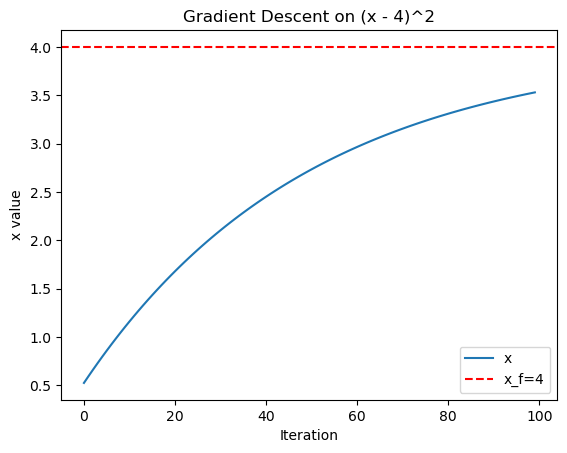

In [7]:
# Define the target value x_f
x_f = 4.0

# Initialize x randomly
x = torch.randn(1)
print("Initial x:", x.item())

# Set learning rate
learning_rate = 1e-2

# Store values of x for visualization
history = []

# Perform gradient descent for 100 iterations
for i in range(100):
    # Convert x to a tensor with gradient tracking
    x_var = torch.tensor(x, requires_grad=True)
    
    # Compute the loss L = (x - x_f)^2
    loss = (x_var - x_f) ** 2
    

    # Backpropagation to compute the gradient of L with respect to x
    loss.backward()
    

    # Update x using gradient descent formula: x ← x - η * dL/dx
    with torch.no_grad():
        x = x_var - learning_rate * x_var.grad
    

    # Store the updated value of x
    history.append(x.item())

# Plot the evolution of x over iterations
plt.plot(history, label='x')
plt.axhline(x_f, color='r', linestyle='--', label='x_f=4')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Gradient Descent on (x - 4)^2')
plt.show()

**Clarification:**
This is gradient descent in its simplest form. In practice, you won’t hand-code updates like this — PyTorch’s built-in optimizers (SGD, Adam, RMSProp) will do it for you. But running it once shows exactly what’s happening behind the scenes.

## 3. Building a Simple Neural Network
**Why you should care:**  
Creating your own neural network will help you understand how deep learning models are structured and function. You'll see how layers, activation functions, and weights work together to make predictions.

**What you'll gain:**  
- Experience in building neural networks step by step.  
- Knowledge of key components like layers and activation functions.  
- A better understanding of forward and backward passes in training.

We'll train a **Multi-Layer Perceptron (MLP)** for digit classification.
Steps:
1. **Load** MNIST data.
2. **Define** an MLP (subclassing `nn.Module`).
3. **Specify** loss function (CrossEntropy) & optimizer (SGD/Adam).
4. **Train** the network.
5. **Evaluate** on the test set.

### 3.1 Load the MNIST Dataset
Using `torchvision.datasets.MNIST` and `DataLoader`.

We'll normalize the images with mean=0.1307 and std=0.3081 (common practice for MNIST).

**Task 11. Complete the code when the comments indicate it with ##**

In [9]:
# Define a transformation pipeline to preprocess the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the images to PyTorch tensors (from PIL or numpy)
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize using mean 0.1307 and std 0.3081 (standard for MNIST)
])

# Load the MNIST training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',  # Path to store the dataset
    train=True,  # Load the training set
    transform=transform,  # Apply the transformation (convert to tensor & normalize)
    download=True  # Download the dataset if not already available
)

# Print the shape of the first image in the dataset
# Print the label of the first image in the dataset
print("Shape of the first training sample:", train_dataset[0][0].shape)  # Expect (1, 28, 28), representing a grayscale image
print("Label of the first training sample:", train_dataset[0][1])  # Print the corresponding label (digit)

## Load the MNIST test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform  =transform,
    download=True
)


# Create DataLoader for the training dataset
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,  # The dataset to load
    batch_size=64,  # Number of samples per batch
    shuffle=True  # Shuffle the dataset to ensure randomness in training
)

## Create DataLoader for the test dataset with batch size 1000 and no shuffling
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=100,
    shuffle=False
)
# The train_loader shuffles data to improve generalization by providing 
# different batches in each epoch, whereas the test_loader does not shuffle to maintain 
# consistent evaluation conditions.

# Print the total number of samples in the training dataset
# Print the total number of samples in the test dataset
print("Number of training samples:", len(train_dataset))  # Expect 60,000 samples
print("Number of testing samples:", len(test_dataset))  # Expect 10,000 samples


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.22MB/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 4.78MB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 3.54MB/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.25MB/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Shape of the first training sample: torch.Size([1, 28, 28])
Label of the first training sample: 5
Number of training samples: 60000
Number of testing samples: 10000


### 3.2 Define a Simple MLP

We'll create a small neural network with the following architecture:

$$
28 \times 28 \rightarrow 128 \rightarrow 10
$$

- The input layer consists of \( 28 * 28 = 784 \) features, representing the flattened pixel values of the image.  
- A hidden layer with 128 neurons using the **ReLU** activation function:  

  $$
  h = \max(0, Wx + b)
  $$

- An output layer with 10 neurons (corresponding to digit classes 0-9), with **no activation function**, since we'll use **CrossEntropyLoss**, which internally applies the softmax function:

  $$
  \hat{y} = Wx + b
  $$

**Task 12. Complete the code when the comments indicate it with ##**

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a simple Multi-Layer Perceptron (MLP) model
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # Flatten layer to convert 2D image (28x28) to a 1D vector (784)
        self.flatten = nn.Flatten()
        ## Fully connected layer: input size 28*28 (784), output size 128
        self.fc1 = nn.Linear(784, 128)
        # Fully connected layer: input size 128, output size 10 (for digit classification)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        # 1) Flatten x to convert the input from shape (batch_size, 1, 28, 28) 
        # to (batch_size, 784). Flattening is needed to feed the data into a fully connected layer.
        x = self.flatten(x)
        
        # 2) Apply the first fully connected layer (fc1) followed by ReLU activation
        # to introduce non-linearity into the model.
        x = F.relu(self.fc1(x))
        
        # 3) Apply the second fully connected layer (fc2) without an activation function.
        # This produces raw logits, which will be used with CrossEntropyLoss that applies softmax internally.
        x = self.fc2(x)
        
        return x

## Instantiate the model
model = SimpleMLP()

## Print the model architecture to verify the structure
print(model)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### 3.3 Define Loss and Optimizer

We commonly use **CrossEntropyLoss** for multi-class classification. Common optimizers include **SGD** (possibly with momentum) or **Adam**.

**Task 13. Complete the code when the comments indicate it with ##**

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
## Alternatively, try Adam:
optimizer1 = torch.optim.Adam(model.parameters(), lr=0.001)

**Task 14. In your words:**
- How can you now tweak hyperparameters (batch size, learning rate, etc.), experiment with **SGD** vs. **Adam** vs. **RMSProp,** and maybe adding more layers or different activations

**My explanation of hyperparameter tuning and experimentation:**

**Hyperparameters I can adjust:**
- **Batch size**: Larger batches (128, 256) provide more stable gradients but use more memory. Smaller batches (32, 16) may help escape local minima.
- **Learning rate**: Higher rates (0.1) train faster but may overshoot the optimum. Lower rates (0.001) are more stable but train slower.
- **Number of epochs**: More epochs allow better learning but risk overfitting.

**Optimizer comparisons:**
- **SGD**: Simple and reliable, but may get stuck in local minima. Adding momentum helps.
- **Adam**: Adapts learning rates automatically, often converges faster and handles different parameter scales well.
- **RMSProp**: Good for recurrent networks and non-stationary objectives.

### 3.4 Training the Model

Training loop steps for each `epoch`:
1. **model.train()** to enable training mode.
2. Loop over **train_loader**:
    - Forward pass -> `outputs`.
    - Compute `loss`.
    - Zero gradients with `optimizer.zero_grad()`.
    - `loss.backward()`.
    - `optimizer.step()`.
3. Track average loss for each epoch.

**Task 15. Complete the COMMENTS when indicate it with ##**

In [18]:
num_epochs = 3  # feel free to adjust

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        # 1) forward
        outputs = model(images) # Forward pass: input images through the model to get predictions 
        # 2) compute loss
        loss = criterion(outputs, labels) # Calculate the loss by comparing predictions with actual labels
        # 3) zero grad
        optimizer.zero_grad() # Clear previous gradients to prevent accumulation from previous iterations
        # 4) backprop
        loss.backward() # Compute gradients of loss with respect to model parameters using backpropagation
        # 5) update
        optimizer.step() # Update model parameters using the computed gradients and learning rate

        running_loss += loss.item() # Add the current batch loss to running total (convert tensor to scalar)

    epoch_loss = running_loss / len(train_loader) # Calculate average loss for this epoch by dividing total loss by number of batches
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/3], Loss: 0.2180
Epoch [2/3], Loss: 0.1937
Epoch [3/3], Loss: 0.1740


**Clarification:**
This is gradient descent at scale. The sequence forward → loss → backward → step is the backbone of all optimization in deep learning.

### 3.5 Evaluate on Test Set

We switch the model to evaluation mode (`model.eval()`) and compute the **accuracy** on the test data.

In [19]:
# Set the model to evaluation mode (turns off dropout, batch normalization, etc.)
model.eval()

# Initialize variables to track the number of correctly classified samples and total samples
correct = 0
total = 0

# Disable gradient calculations during inference to improve efficiency and save memory
with torch.no_grad():
    # Iterate over the test dataset batches
    for images, labels in test_loader:
        # Perform forward pass to get model predictions (logits)
        outputs = model(images)
        
        # Get the class index with the highest probability (predicted label)
        _, predicted = torch.max(outputs, 1)

        # Update the total number of test samples
        total += labels.size(0)

        # Count the number of correct predictions
        correct += (predicted == labels).sum().item()

# Calculate accuracy as the percentage of correctly classified samples
accuracy = 100.0 * correct / total

# Print the final test accuracy
print(f"Test Accuracy: {accuracy:.2f}%")



Test Accuracy: 95.24%


**Task 16. In your words, explain what happend in the block code indcluded above for evaluating in the test**



1.  `model.eval()` disables training-specific behaviors like dropout and batch normalization updates, ensuring consistent predictions.

2.  `correct = 0` and `total = 0` track the number of correctly classified samples and total samples processed.

3. `with torch.no_grad():` turns off gradient computation during inference to:
   - Save memory (no need to store intermediate values for backprop)
   - Speed up computation
   - Prevent accidental parameter updates

4. Loop through test_loader to process all test data in batches.

5.  `accuracy = 100.0 * correct / total` gives percentage of correctly classified test samples.


**Implementation Gift: Visualize a batch of images with predictions**

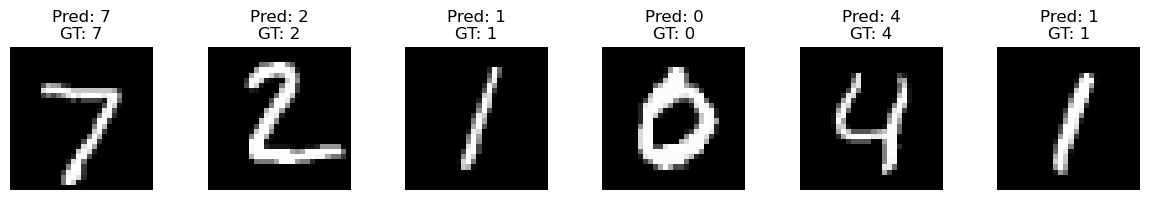

In [20]:
# Get a batch of test images and labels
model.eval()
images, labels = next(iter(test_loader))

# Forward pass to get outputs and predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Pick how many samples to visualize
num_samples_to_show = 6
fig, axes = plt.subplots(1, num_samples_to_show, figsize=(12, 2))

for i in range(num_samples_to_show):
    # Move from PyTorch tensor -> NumPy for plotting
    img = images[i].squeeze().numpy()
    ax = axes[i]
    ax.imshow(img, cmap='gray')
    
    # Set title: prediction vs ground truth
    ax.set_title(f"Pred: {predicted[i].item()}\nGT: {labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()


**Final Reflection**

- You practiced using tensors, autograd, gradient descent, and a full training loop.
- In practice, you won’t code autograd or parameter updates manually — but now you know what they are doing under the hood.
- Optimization is the unifying thread: it drives every update from a simple scalar 
𝑥 to the millions of weights in a neural network.